# SCNN v5 — Calibration-Based Training

Key change: **S2 trains on 3 spread positions** (p0, p3, p6) instead of p0 only.
This simulates real-world calibration where user does gestures at a few positions during setup.

Also: S3 uses partial circular augmentation (4 rotations, not 8) to add diversity without killing runtime.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import mode
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import MODELS_DIR, RANDOM_SEED, N_CLASSES, get_device, SUBJECTS_NON_FATIGUE
from src.data_splitter import (
    load_metadata, load_windows_from_metadata,
    compute_normalization_stats, apply_normalization,
    scenario_1_ideal, scenario_3_inter_subject,
    scenario_4_interday, scenario_5_fatigue,
)
from src.feature_extraction import fht_envelope_batch
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## Model + augmentation (same as v4)

In [2]:
import math

class ECAModule(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        k_size = int(abs(math.log2(channels) / gamma + b / gamma))
        k_size = k_size if k_size % 2 else k_size + 1
        k_size = max(k_size, 3)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=k_size // 2, bias=False)
    def forward(self, x):
        b, c, h, w = x.size()
        y = self.avg_pool(x).view(b, 1, c)
        y = torch.sigmoid(self.conv(y)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, padding=padding, groups=in_ch)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x): return self.pointwise(self.depthwise(x))

class SCNN_ECA(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.block1 = nn.Sequential(DepthwiseSeparableConv(1, 48, 3, 1), nn.BatchNorm2d(48), nn.ReLU())
        self.eca1 = ECAModule(48)
        self.pool1 = nn.MaxPool2d(2)
        self.block2 = nn.Sequential(DepthwiseSeparableConv(48, 96, 3, 1), nn.BatchNorm2d(96), nn.ReLU())
        self.eca2 = ECAModule(96)
        self.pool2 = nn.MaxPool2d(2)
        self.block3 = nn.Sequential(DepthwiseSeparableConv(96, 192, 3, 1), nn.BatchNorm2d(192), nn.ReLU())
        self.eca3 = ECAModule(192)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(192, 96), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(96, n_classes),
        )
    def forward(self, x):
        x = self.pool1(self.eca1(self.block1(x)))
        x = self.pool2(self.eca2(self.block2(x)))
        x = self.gap(self.eca3(self.block3(x)))
        return self.classifier(x)

print(f"Parameters: {sum(p.numel() for p in SCNN_ECA().parameters()):,}")

Parameters: 44,764


In [3]:
def circular_augment(X, y, n_rotations=8):
    N, C, T = X.shape
    X_aug = np.empty((N * n_rotations, C, T), dtype=X.dtype)
    y_aug = np.empty(N * n_rotations, dtype=y.dtype)
    for shift in range(n_rotations):
        X_aug[shift * N:(shift + 1) * N] = np.roll(X, shift=shift, axis=1)
        y_aug[shift * N:(shift + 1) * N] = y
    idx = np.random.RandomState(RANDOM_SEED).permutation(len(y_aug))
    return X_aug[idx], y_aug[idx]


def circular_tta_predict(model, X_fht, device=DEVICE):
    model.eval()
    N, C, T = X_fht.shape
    all_preds = np.zeros((8, N), dtype=np.int64)
    for shift in range(8):
        X_shifted = np.roll(X_fht, shift=shift, axis=1)
        X_t = torch.from_numpy(X_shifted).float().unsqueeze(1)
        loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
        preds = []
        with torch.no_grad():
            for (xb,) in loader:
                preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
        all_preds[shift] = np.concatenate(preds)
    return mode(all_preds, axis=0, keepdims=False).mode


class NoisyDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, noise_std=0.15):
        self.X = torch.from_numpy(X).float().unsqueeze(1)
        self.y = torch.from_numpy(y).long()
        self.noise_std = noise_std
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx]
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return x, self.y[idx]


def make_loader(X_fht, y, noise_std=0.15, batch_size=256):
    ds = NoisyDataset(X_fht, y, noise_std=noise_std)
    return DataLoader(ds, batch_size=batch_size, shuffle=True)


def train_model(model, train_loader, n_epochs=50, lr=3e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=n_epochs, steps_per_epoch=len(train_loader)
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} — loss: {total_loss/total:.4f}, acc: {correct/total:.4f}")


@torch.no_grad()
def predict(model, X_fht):
    model.eval()
    X_t = torch.from_numpy(X_fht).float().unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

---
## Scenario 1 — Ideal

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 2136.32it/s]


Train: (59159, 8, 50), Test: (29281, 8, 50)
Epoch   1/50 — loss: 1.7510, acc: 0.3416
Epoch   5/50 — loss: 1.1902, acc: 0.6429
Epoch  10/50 — loss: 1.0704, acc: 0.7080
Epoch  15/50 — loss: 0.9874, acc: 0.7509
Epoch  20/50 — loss: 0.9264, acc: 0.7826
Epoch  25/50 — loss: 0.8848, acc: 0.8035
Epoch  30/50 — loss: 0.8507, acc: 0.8178
Epoch  35/50 — loss: 0.8208, acc: 0.8354
Epoch  40/50 — loss: 0.7946, acc: 0.8509
Epoch  45/50 — loss: 0.7779, acc: 0.8580
Epoch  50/50 — loss: 0.7751, acc: 0.8608

  v5 — S1 Ideal
  Accuracy:  0.7632
  F1-macro:  0.7647
                    precision    recall  f1-score   support

              fist       0.86      0.88      0.87      4208
         open_hand       0.77      0.68      0.72      4179
  pinch_forefinger       0.62      0.66      0.64      4204
pinch_middlefinger       0.66      0.72      0.69      4239
               two       0.72      0.80      0.76      4175
          eversion       0.85      0.80      0.82      4064
             varus       0.

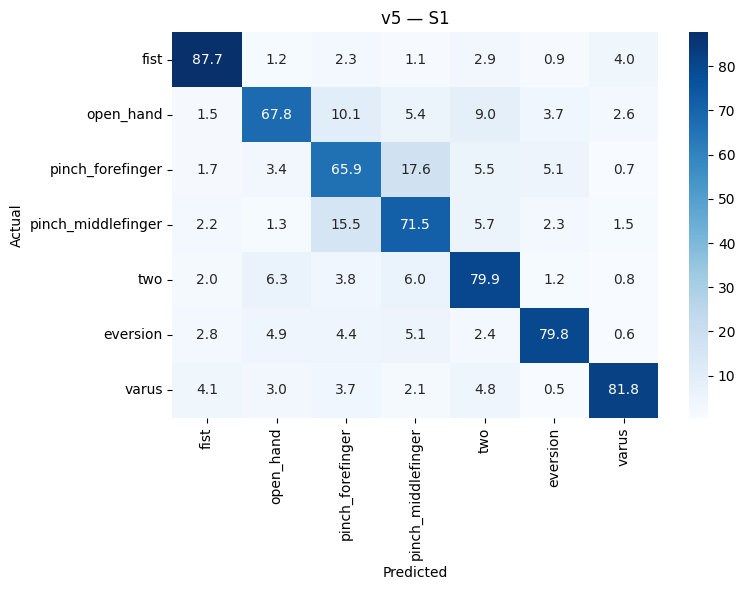

array([[3689,   50,   95,   45,  123,   36,  170],
       [  64, 2832,  420,  226,  375,  154,  108],
       [  70,  145, 2770,  739,  233,  216,   31],
       [  94,   53,  657, 3032,  240,   99,   64],
       [  84,  263,  157,  250, 3334,   52,   35],
       [ 114,  198,  180,  207,   96, 3244,   25],
       [ 171,  126,  157,   89,  203,   21, 3445]])

In [4]:
X_train, y_train, X_test, y_test, info = scenario_1_ideal()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

X_train_fht = fht_envelope_batch(X_train)
X_test_fht = fht_envelope_batch(X_test)

loader_s1 = make_loader(X_train_fht, y_train)
scnn_s1 = SCNN_ECA().to(DEVICE)
train_model(scnn_s1, loader_s1, n_epochs=50)

y_pred = predict(scnn_s1, X_test_fht)
metrics_s1 = print_report(y_test, y_pred, title="v5 — S1 Ideal")
plot_confusion_matrix(y_test, y_pred, title="v5 — S1")

In [21]:
# Per-subject evaluation
from src.data_splitter import load_metadata, load_windows_from_metadata, compute_normalization_stats, apply_normalization

meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["position"] == 0)]

per_subject_acc = {}
for subj in sorted(subset["subject"].unique()):
    subj_df = subset[subset["subject"] == subj]
    train_df = subj_df[subj_df["repetition"].isin([0, 1])]
    test_df = subj_df[subj_df["repetition"] == 2]

    X_tr, y_tr = load_windows_from_metadata(train_df, verbose=False)
    X_te, y_te = load_windows_from_metadata(test_df, verbose=False)

    mean, std = compute_normalization_stats(X_tr)
    X_tr = apply_normalization(X_tr, mean, std)
    X_te = apply_normalization(X_te, mean, std)

    X_tr_fht = fht_envelope_batch(X_tr)
    X_te_fht = fht_envelope_batch(X_te)

    m = SCNN_ECA().to(DEVICE)
    loader = make_loader(X_tr_fht, y_tr, batch_size=128)
    train_model(m, loader, n_epochs=50, lr=3e-3)
    y_pred = predict(m, X_te_fht)
    per_subject_acc[subj] = accuracy_score(y_te, y_pred)

accs = list(per_subject_acc.values())
print(f"\nPer-subject accuracy: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
print()
for subj, acc in sorted(per_subject_acc.items()):
    bar = "█" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Epoch   1/50 — loss: 1.9426, acc: 0.1531
Epoch   5/50 — loss: 1.5705, acc: 0.6387
Epoch  10/50 — loss: 0.7200, acc: 0.9052
Epoch  15/50 — loss: 0.6786, acc: 0.9225
Epoch  20/50 — loss: 0.6473, acc: 0.9289
Epoch  25/50 — loss: 0.6427, acc: 0.9295
Epoch  30/50 — loss: 0.6308, acc: 0.9276
Epoch  35/50 — loss: 0.6218, acc: 0.9295
Epoch  40/50 — loss: 0.6111, acc: 0.9404
Epoch  45/50 — loss: 0.6084, acc: 0.9366
Epoch  50/50 — loss: 0.6069, acc: 0.9379
Epoch   1/50 — loss: 1.9355, acc: 0.1697
Epoch   5/50 — loss: 1.7439, acc: 0.4303
Epoch  10/50 — loss: 1.0286, acc: 0.7339
Epoch  15/50 — loss: 0.8818, acc: 0.8199
Epoch  20/50 — loss: 0.8062, acc: 0.8558
Epoch  25/50 — loss: 0.7531, acc: 0.8869
Epoch  30/50 — loss: 0.7260, acc: 0.8908
Epoch  35/50 — loss: 0.6956, acc: 0.9060
Epoch  40/50 — loss: 0.6727, acc: 0.9235
Epoch  45/50 — loss: 0.6599, acc: 0.9211
Epoch  50/50 — loss: 0.6672, acc: 0.9235
Epoch   1/50 — loss: 1.9323, acc: 0.1777
Epoch   5/50 — loss: 1.4514, acc: 0.5941
Epoch  10/50 — l

---
## Scenario 2 — Electrode Shift with CALIBRATION

**New setup**: Train on 3 spread positions (p0, p3, p6) + circular augmentation + TTA.
Test on remaining 8 positions (p1, p2, p4, p5, p7, p8, p9, p10).

This simulates real-world calibration: user does gestures at 3 arm positions during initial setup.

In [5]:
# Custom S2 split: train on p0, p3, p6 — test on remaining
meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["subject"].isin(SUBJECTS_NON_FATIGUE))]

TRAIN_POSITIONS = [0, 3, 6]
TEST_POSITIONS = [p for p in range(11) if p not in TRAIN_POSITIONS]

train_df = subset[subset["position"].isin(TRAIN_POSITIONS)]
test_df = subset[subset["position"].isin(TEST_POSITIONS)]

print(f"Train positions: {TRAIN_POSITIONS}")
print(f"Test positions:  {TEST_POSITIONS}")

X_train_s2, y_train_s2 = load_windows_from_metadata(train_df)
print(f"\nTrain: {X_train_s2.shape}")

# Normalize
mean, std = compute_normalization_stats(X_train_s2)
X_train_s2 = apply_normalization(X_train_s2, mean, std)

# FHT + circular augmentation
X_train_s2_fht = fht_envelope_batch(X_train_s2)
X_train_s2_aug, y_train_s2_aug = circular_augment(X_train_s2_fht, y_train_s2, n_rotations=8)
print(f"After FHT + circular aug: {X_train_s2_aug.shape[0]:,} windows")

Train positions: [0, 3, 6]
Test positions:  [1, 2, 4, 5, 7, 8, 9, 10]


Loading windows: 100%|██████████| 1887/1887 [00:00<00:00, 2687.87it/s]



Train: (214696, 8, 50)
After FHT + circular aug: 1,717,568 windows


In [6]:
loader_s2 = make_loader(X_train_s2_aug, y_train_s2_aug)
scnn_s2 = SCNN_ECA().to(DEVICE)
train_model(scnn_s2, loader_s2, n_epochs=50)

Epoch   1/50 — loss: 1.6246, acc: 0.4036
Epoch   5/50 — loss: 1.4428, acc: 0.5089
Epoch  10/50 — loss: 1.3838, acc: 0.5416
Epoch  15/50 — loss: 1.3769, acc: 0.5463
Epoch  20/50 — loss: 1.3627, acc: 0.5540
Epoch  25/50 — loss: 1.3486, acc: 0.5610
Epoch  30/50 — loss: 1.3300, acc: 0.5704
Epoch  35/50 — loss: 1.3096, acc: 0.5814
Epoch  40/50 — loss: 1.2875, acc: 0.5930
Epoch  45/50 — loss: 1.2673, acc: 0.6036
Epoch  50/50 — loss: 1.2586, acc: 0.6077


In [7]:
# Evaluate per test position — with and without TTA
acc_no_tta = {}
acc_tta = {}

for pos in TEST_POSITIONS:
    pos_df = subset[subset["position"] == pos]
    X_pos, y_pos = load_windows_from_metadata(pos_df, verbose=False)
    X_pos = apply_normalization(X_pos, mean, std)
    X_pos_fht = fht_envelope_batch(X_pos)

    # Without TTA
    y_pred = predict(scnn_s2, X_pos_fht)
    acc_no_tta[pos] = accuracy_score(y_pos, y_pred)

    # With TTA
    y_pred_tta = circular_tta_predict(scnn_s2, X_pos_fht)
    acc_tta[pos] = accuracy_score(y_pos, y_pred_tta)

    print(f"Position {pos:2d}: no_TTA={acc_no_tta[pos]:.4f}  TTA={acc_tta[pos]:.4f}  Δ={acc_tta[pos]-acc_no_tta[pos]:+.4f}")

print(f"\nAvg no TTA: {np.mean(list(acc_no_tta.values())):.4f}")
print(f"Avg TTA:    {np.mean(list(acc_tta.values())):.4f}")

Position  1: no_TTA=0.5264  TTA=0.5499  Δ=+0.0235
Position  2: no_TTA=0.5467  TTA=0.5717  Δ=+0.0250
Position  4: no_TTA=0.5427  TTA=0.5725  Δ=+0.0298
Position  5: no_TTA=0.5661  TTA=0.5904  Δ=+0.0243
Position  7: no_TTA=0.5153  TTA=0.5521  Δ=+0.0368
Position  8: no_TTA=0.5463  TTA=0.5705  Δ=+0.0242
Position  9: no_TTA=0.5724  TTA=0.5958  Δ=+0.0234
Position 10: no_TTA=0.5451  TTA=0.5715  Δ=+0.0264

Avg no TTA: 0.5451
Avg TTA:    0.5718


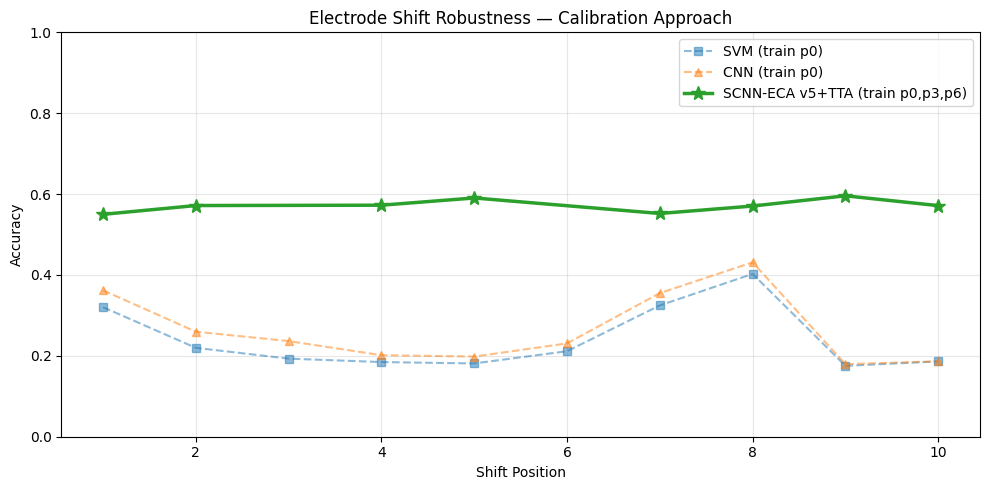

In [8]:
# Comparison plot
svm_shift =  [0.3203, 0.2198, 0.1931, 0.1846, 0.1812, 0.2115, 0.3247, 0.4026, 0.1753, 0.1862]
cnn_shift =  [0.3620, 0.2597, 0.2365, 0.2016, 0.1982, 0.2308, 0.3552, 0.4312, 0.1794, 0.1866]

# v4 was train-on-p0, test p1-p10 (all 10 positions)
# v5 is train-on-p0,p3,p6, test remaining 8 positions — different x-axis

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), svm_shift, "s--", label="SVM (train p0)", alpha=0.5)
plt.plot(range(1, 11), cnn_shift, "^--", label="CNN (train p0)", alpha=0.5)

v5_positions = TEST_POSITIONS
v5_accs = [acc_tta[p] for p in v5_positions]
plt.plot(v5_positions, v5_accs, "*-", label="SCNN-ECA v5+TTA (train p0,p3,p6)", linewidth=2.5, markersize=10)

plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("Electrode Shift Robustness — Calibration Approach")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "v5_shift_calibration.png"), dpi=150)
plt.show()

In [9]:
torch.save(scnn_s2.state_dict(), MODELS_DIR / "scnn_v5_s2_calibration.pt")
print("Saved.")

Saved.


---
## Scenario 3 — Inter-Subject (partial circular aug, 4 rotations)

In [10]:
X_train_s3, y_train_s3, X_test_s3, y_test_s3, info_s3 = scenario_3_inter_subject()
print(f"Train: {X_train_s3.shape} ({len(info_s3['train_subjects'])} subjects)")
print(f"Test:  {X_test_s3.shape} ({info_s3['test_subjects']})")

X_train_s3_fht = fht_envelope_batch(X_train_s3)
X_test_s3_fht = fht_envelope_batch(X_test_s3)

Loading windows: 100%|██████████| 1385/1385 [00:00<00:00, 2629.97it/s]


Train: (618926, 8, 50) (24 subjects)
Test:  (168232, 8, 50) (['h7', 'h22', 'h3', 'h24', 'h16', 'h17'])


In [11]:
# Partial circular augmentation: 4 rotations (0, 2, 4, 6) instead of all 8
X_s3_aug, y_s3_aug = circular_augment(X_train_s3_fht, y_train_s3, n_rotations=4)
print(f"After 4-rotation aug: {X_s3_aug.shape[0]:,} windows")

loader_s3 = make_loader(X_s3_aug, y_s3_aug)
scnn_s3 = SCNN_ECA().to(DEVICE)
train_model(scnn_s3, loader_s3, n_epochs=50)

After 4-rotation aug: 2,475,704 windows
Epoch   1/50 — loss: 1.5662, acc: 0.4366
Epoch   5/50 — loss: 1.3571, acc: 0.5535
Epoch  10/50 — loss: 1.3131, acc: 0.5772
Epoch  15/50 — loss: 1.3071, acc: 0.5805
Epoch  20/50 — loss: 1.3006, acc: 0.5848
Epoch  25/50 — loss: 1.2886, acc: 0.5909
Epoch  30/50 — loss: 1.2739, acc: 0.5985
Epoch  35/50 — loss: 1.2542, acc: 0.6089
Epoch  40/50 — loss: 1.2336, acc: 0.6195
Epoch  45/50 — loss: 1.2146, acc: 0.6296
Epoch  50/50 — loss: 1.2055, acc: 0.6341



  v5 — S3 Inter-Subject
  Accuracy:  0.4929
  F1-macro:  0.4888
                    precision    recall  f1-score   support

              fist       0.54      0.50      0.52     23888
         open_hand       0.47      0.57      0.51     23933
  pinch_forefinger       0.37      0.36      0.37     24284
pinch_middlefinger       0.40      0.30      0.34     24064
               two       0.56      0.57      0.56     23897
          eversion       0.61      0.67      0.64     24069
             varus       0.47      0.48      0.48     24097

          accuracy                           0.49    168232
         macro avg       0.49      0.49      0.49    168232
      weighted avg       0.49      0.49      0.49    168232



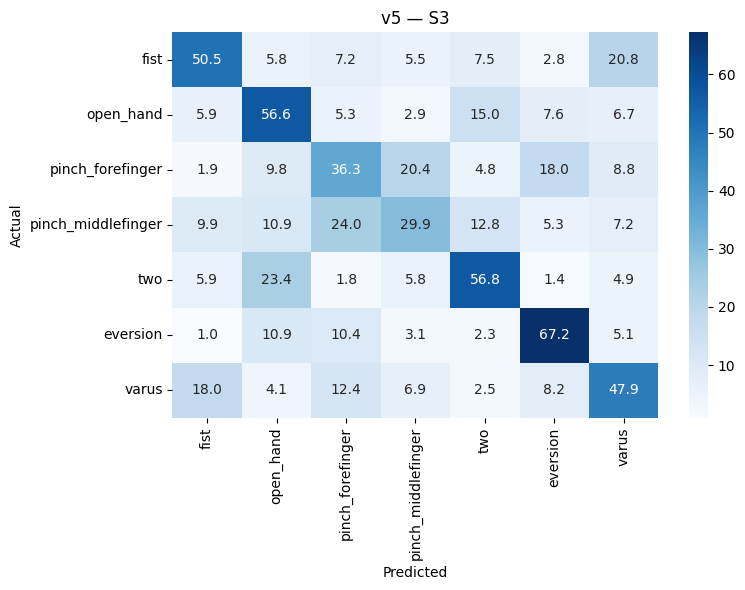

array([[12059,  1385,  1721,  1307,  1781,   673,  4962],
       [ 1419, 13558,  1261,   687,  3598,  1812,  1598],
       [  458,  2387,  8807,  4956,  1177,  4368,  2131],
       [ 2376,  2612,  5766,  7193,  3088,  1287,  1742],
       [ 1402,  5603,   436,  1378, 13578,   332,  1168],
       [  234,  2617,  2504,   753,   551, 16181,  1229],
       [ 4333,   984,  2992,  1653,   613,  1976, 11546]])

In [12]:
y_pred_s3 = predict(scnn_s3, X_test_s3_fht)
metrics_s3 = print_report(y_test_s3, y_pred_s3, title="v5 — S3 Inter-Subject")
plot_confusion_matrix(y_test_s3, y_pred_s3, title="v5 — S3")

In [13]:
# Also try TTA on S3
y_pred_s3_tta = circular_tta_predict(scnn_s3, X_test_s3_fht)
metrics_s3_tta = print_report(y_test_s3, y_pred_s3_tta, title="v5 — S3 Inter-Subject + TTA")


  v5 — S3 Inter-Subject + TTA
  Accuracy:  0.5115
  F1-macro:  0.5066
                    precision    recall  f1-score   support

              fist       0.53      0.55      0.54     23888
         open_hand       0.48      0.63      0.54     23933
  pinch_forefinger       0.39      0.39      0.39     24284
pinch_middlefinger       0.44      0.30      0.36     24064
               two       0.58      0.56      0.57     23897
          eversion       0.64      0.68      0.66     24069
             varus       0.51      0.47      0.49     24097

          accuracy                           0.51    168232
         macro avg       0.51      0.51      0.51    168232
      weighted avg       0.51      0.51      0.51    168232



---
## Scenario 4 — Inter-Day

In [14]:
X_train_s4, y_train_s4, test_by_sess, info_s4 = scenario_4_interday()
print(f"Train: {X_train_s4.shape}")

X_train_s4_fht = fht_envelope_batch(X_train_s4)
loader_s4 = make_loader(X_train_s4_fht, y_train_s4)
scnn_s4 = SCNN_ECA().to(DEVICE)
train_model(scnn_s4, loader_s4, n_epochs=50)

Loading windows: 100%|██████████| 126/126 [00:00<00:00, 2239.40it/s]


Train: (13445, 8, 50)
Epoch   1/50 — loss: 1.9037, acc: 0.2413
Epoch   5/50 — loss: 1.1591, acc: 0.6717
Epoch  10/50 — loss: 0.9880, acc: 0.7435
Epoch  15/50 — loss: 0.9124, acc: 0.7859
Epoch  20/50 — loss: 0.8535, acc: 0.8179
Epoch  25/50 — loss: 0.8151, acc: 0.8397
Epoch  30/50 — loss: 0.7851, acc: 0.8551
Epoch  35/50 — loss: 0.7559, acc: 0.8696
Epoch  40/50 — loss: 0.7340, acc: 0.8833
Epoch  45/50 — loss: 0.7179, acc: 0.8920
Epoch  50/50 — loss: 0.7197, acc: 0.8884


In [15]:
acc_per_sess = {}
for sess, (X_s, y_s) in sorted(test_by_sess.items()):
    X_s_fht = fht_envelope_batch(X_s)
    y_pred = predict(scnn_s4, X_s_fht)
    acc_per_sess[sess] = accuracy_score(y_s, y_pred)
    print(f"Session {sess}: acc = {acc_per_sess[sess]:.4f}")

print(f"\nAvg: {np.mean(list(acc_per_sess.values())):.4f}")

Session 1: acc = 0.5499
Session 2: acc = 0.6614
Session 3: acc = 0.6546
Session 4: acc = 0.6370
Session 5: acc = 0.5614
Session 6: acc = 0.6474
Session 7: acc = 0.5841
Session 8: acc = 0.6601
Session 9: acc = 0.5534

Avg: 0.6122


---
## Scenario 5 — Fatigue

In [16]:
X_train_s5, y_train_s5, test_by_fatigue, info_s5 = scenario_5_fatigue()
print(f"Train: {X_train_s5.shape}")

X_train_s5_fht = fht_envelope_batch(X_train_s5)
loader_s5 = make_loader(X_train_s5_fht, y_train_s5)
scnn_s5 = SCNN_ECA().to(DEVICE)
train_model(scnn_s5, loader_s5, n_epochs=50)

Loading windows: 100%|██████████| 252/252 [00:00<00:00, 2520.86it/s]


Train: (33046, 8, 50)
Epoch   1/50 — loss: 1.8266, acc: 0.3308
Epoch   5/50 — loss: 0.9306, acc: 0.7854
Epoch  10/50 — loss: 0.7955, acc: 0.8488
Epoch  15/50 — loss: 0.7411, acc: 0.8759
Epoch  20/50 — loss: 0.7040, acc: 0.8894
Epoch  25/50 — loss: 0.6831, acc: 0.9006
Epoch  30/50 — loss: 0.6588, acc: 0.9095
Epoch  35/50 — loss: 0.6419, acc: 0.9198
Epoch  40/50 — loss: 0.6262, acc: 0.9269
Epoch  45/50 — loss: 0.6143, acc: 0.9312
Epoch  50/50 — loss: 0.6131, acc: 0.9319


In [17]:
acc_per_fatigue = {}
for pos, (X_p, y_p) in sorted(test_by_fatigue.items()):
    X_p_fht = fht_envelope_batch(X_p)
    y_pred = predict(scnn_s5, X_p_fht)
    acc_per_fatigue[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_fatigue[pos]:.4f}")

print(f"\nAvg: {np.mean(list(acc_per_fatigue.values())):.4f}")

Position  2: acc = 0.8717
Position  3: acc = 0.8515
Position  4: acc = 0.8615
Position  5: acc = 0.8748
Position  6: acc = 0.8613
Position  7: acc = 0.8712
Position  8: acc = 0.8192
Position  9: acc = 0.8309
Position 10: acc = 0.8166

Avg: 0.8510


---
## Latency

In [18]:
scnn_s1.eval()
sample_raw = X_train[:1]

sample_fht = torch.from_numpy(fht_envelope_batch(sample_raw)).float().unsqueeze(1).to(DEVICE)
for _ in range(10):
    _ = scnn_s1(sample_fht)
if DEVICE.type == "mps":
    torch.mps.synchronize()

def v5_predict_single(x_raw):
    x_fht = fht_envelope_batch(x_raw)
    x_t = torch.from_numpy(x_fht).float().unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        out = scnn_s1(x_t)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

latency = measure_latency(v5_predict_single, sample_raw, n_runs=500)
print_latency(latency, model_name="SCNN-ECA v5")
print(f"Parameters: {sum(p.numel() for p in scnn_s1.parameters()):,}")


Latency — SCNN-ECA v5
  Mean:   1.30 ms
  Median: 1.23 ms
  P95:    1.47 ms
  <300ms: ✓
Parameters: 44,764


---
## Full Comparison

In [20]:
n_params = sum(p.numel() for p in scnn_s1.parameters())
s2_avg = np.mean(list(acc_tta.values()))
s3_best = max(metrics_s3['accuracy'], metrics_s3_tta['accuracy'])
s3_label = "S3 (TTA)" if metrics_s3_tta['accuracy'] > metrics_s3['accuracy'] else "S3"

print("\n" + "=" * 75)
print("FULL COMPARISON — ALL METHODS")
print("=" * 75)
print(f"{'Metric':<22} {'SVM':>8} {'CNN':>8} {'SCNN v1':>8} {'SCNN v4+TTA':>8} {'SCNN v5+cal':>8}")
print("-" * 75)
print(f"{'S1 Ideal':<22} {'65.19%':>8} {'75.78%':>8} {'71.80%':>8} {'76.32%':>8} {metrics_s1['accuracy']*100:>7.2f}%")
print(f"{'S2 Shift (avg)':<22} {'23.99%':>8} {'26.41%':>8} {'24.78%':>8} {'32.27%':>8} {s2_avg*100:>7.2f}%")
print(f"{'S3 Inter-subject':<22} {'40.27%':>8} {'52.90%':>8} {'48.51%':>8} {'46.70%':>8} {s3_best*100:>7.2f}%")
print(f"{'S4 Inter-day':<22} {'63.03%':>8} {'67.30%':>8} {'62.79%':>8} {'65.60%':>8} {np.mean(list(acc_per_sess.values()))*100:>7.2f}%")
print(f"{'S5 Fatigue':<22} {'81.20%':>8} {'86.98%':>8} {'84.96%':>8} {'87.46%':>8} {np.mean(list(acc_per_fatigue.values()))*100:>7.2f}%")
print(f"{'Latency p95 (ms)':<22} {'5.40':>8} {'1.74':>8} {'2.10':>8} {'1.67':>8} {latency['p95_ms']:>7.2f}")
print(f"{'Parameters':<22} {'—':>8} {'101,831':>8} {'20,625':>8} {'44,764':>8} {n_params:>8,}")
print("=" * 75)
print(f"\nNote: S2 v5 uses calibration (train p0,p3,p6) vs v4 (train p0 only).")
print(f"      S3 v5 uses 4-rotation circular augmentation + optional TTA.")


FULL COMPARISON — ALL METHODS
Metric                      SVM      CNN  SCNN v1 SCNN v4+TTA SCNN v5+cal
---------------------------------------------------------------------------
S1 Ideal                 65.19%   75.78%   71.80%   76.32%   76.32%
S2 Shift (avg)           23.99%   26.41%   24.78%   32.27%   57.18%
S3 Inter-subject         40.27%   52.90%   48.51%   46.70%   51.15%
S4 Inter-day             63.03%   67.30%   62.79%   65.60%   61.22%
S5 Fatigue               81.20%   86.98%   84.96%   87.46%   85.10%
Latency p95 (ms)           5.40     1.74     2.10     1.67    1.47
Parameters                    —  101,831   20,625   44,764   44,764

Note: S2 v5 uses calibration (train p0,p3,p6) vs v4 (train p0 only).
      S3 v5 uses 4-rotation circular augmentation + optional TTA.
